# PCA from first principles: eigen-decomposition vs scikit-learn
**Problem:** `sklearn.decomposition.PCA` is one line of code, but what does it actually compute? This notebook builds principal component analysis from linear algebra and checks it against scikit-learn number for number.
**Approach:** standardise the features, form the covariance matrix, eigen-decompose it (`numpy.linalg.eigh`), sort the eigenpairs, project the data, and measure how much variance each component keeps. Then fit scikit-learn's PCA and verify that the explained variance, the components (up to sign) and the projected coordinates agree. It closes with the SVD route and a reconstruction-error curve.
**Data:** the Iris dataset bundled with scikit-learn (150 flowers × 4 measurements), a public dataset.
**Companion to:** `pca.ipynb`, which shows the scikit-learn one-liner.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

iris = load_iris()
X, y = iris.data, iris.target
print(X.shape, iris.feature_names)

(150, 4) ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


## 1. Standardise
PCA looks for directions of maximum variance, so features measured on larger scales would dominate. Each column is centred to mean 0 and scaled to unit variance. The population standard deviation (`ddof=0`) matches `StandardScaler`.

In [2]:
mu = X.mean(axis=0)
sigma = X.std(axis=0, ddof=0)
Z = (X - mu) / sigma
print("means ≈ 0:", np.allclose(Z.mean(axis=0), 0), "| std = 1:", np.allclose(Z.std(axis=0), 1))

means ≈ 0: True | std = 1: True


## 2. Covariance matrix and its eigen-decomposition
For centred data, the sample covariance is $C = \frac{1}{n-1} Z^\top Z$. It's symmetric, so `eigh` applies: it's faster and more stable than `eig`, and guarantees real eigenvalues. Each eigenvector is a principal axis, and its eigenvalue is the variance of the data along that axis.

In [3]:
n = Z.shape[0]
C = Z.T @ Z / (n - 1)
assert np.allclose(C, np.cov(Z, rowvar=False))       # same as numpy's estimator

eigvals, eigvecs = np.linalg.eigh(C)                  # ascending order
order = np.argsort(eigvals)[::-1]                     # largest variance first
eigvals, eigvecs = eigvals[order], eigvecs[:, order]  # columns are the principal axes

explained_ratio = eigvals / eigvals.sum()
for i, (lam, r) in enumerate(zip(eigvals, explained_ratio), 1):
    print(f"PC{i}: variance {lam:.3f}  ({r:6.1%} of total, cumulative {explained_ratio[:i].sum():6.1%})")

PC1: variance 2.938  ( 73.0% of total, cumulative  73.0%)
PC2: variance 0.920  ( 22.9% of total, cumulative  95.8%)
PC3: variance 0.148  (  3.7% of total, cumulative  99.5%)
PC4: variance 0.021  (  0.5% of total, cumulative 100.0%)


## 3. How many components? (scree plot)

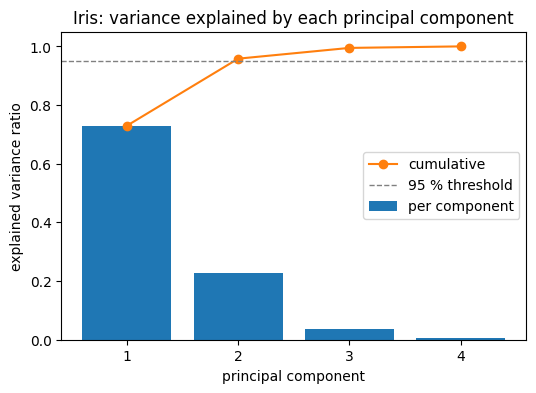

In [4]:
k = np.arange(1, len(eigvals) + 1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(k, explained_ratio, label="per component")
ax.plot(k, np.cumsum(explained_ratio), "o-", color="C1", label="cumulative")
ax.axhline(0.95, ls="--", color="grey", lw=1, label="95 % threshold")
ax.set_xticks(k)
ax.set_xlabel("principal component")
ax.set_ylabel("explained variance ratio")
ax.set_title("Iris: variance explained by each principal component")
ax.legend()
plt.show()

## 4. Project onto the first two components
Projecting onto the first two axes (`Z @ W`) keeps about 96 % of the variance in 2-D.

In [5]:
W = eigvecs[:, :2]            # 4 x 2 projection matrix
scores = Z @ W                # 150 x 2 coordinates in PC space
print("projection matrix W:\n", np.round(W, 3))

projection matrix W:
 [[-0.521  0.377]
 [ 0.269  0.923]
 [-0.58   0.024]
 [-0.565  0.067]]


## 5. Check against scikit-learn
Eigenvectors are only defined up to sign (both $v$ and $-v$ are valid axes), so each component is sign-aligned before comparing.

In [6]:
pca = PCA(n_components=4).fit(Z)

def align_signs(reference: np.ndarray, other: np.ndarray) -> np.ndarray:
    """Flip each column of `other` so it points the same way as the matching column of `reference`."""
    signs = np.sign(np.sum(reference * other, axis=0))
    return other * signs

ours = eigvecs                                   # columns = components
theirs = align_signs(ours, pca.components_.T)    # sklearn stores components as rows

checks = {
    "explained variance (eigenvalues)": np.allclose(eigvals, pca.explained_variance_),
    "explained variance ratio": np.allclose(explained_ratio, pca.explained_variance_ratio_),
    "principal axes (up to sign)": np.allclose(ours, theirs),
    "2-D projected coordinates": np.allclose(scores, align_signs(scores, pca.transform(Z)[:, :2])),
}
for name, ok in checks.items():
    print(f"{'OK ' if ok else 'MISMATCH'}  {name}")
assert all(checks.values())

OK   explained variance (eigenvalues)
OK   explained variance ratio
OK   principal axes (up to sign)
OK   2-D projected coordinates


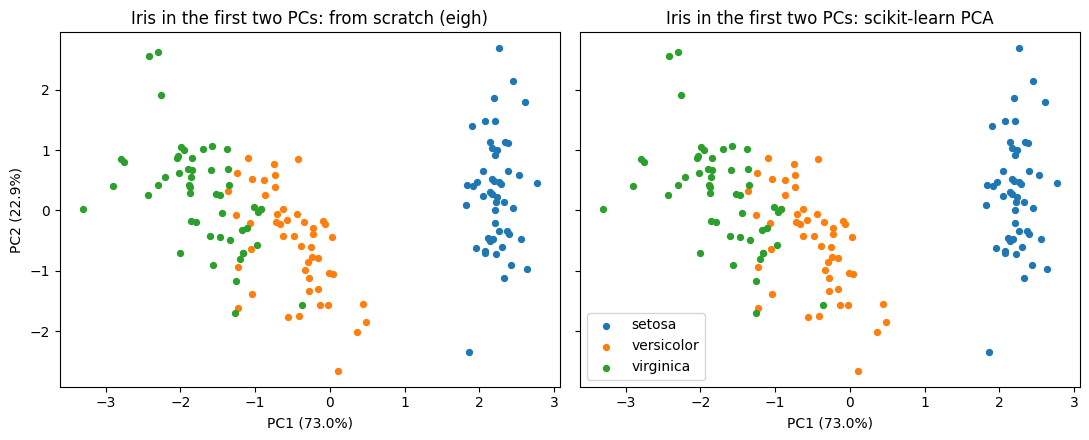

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
sk_scores = align_signs(scores, pca.transform(Z)[:, :2])
for ax, S, title in [(axes[0], scores, "from scratch (eigh)"), (axes[1], sk_scores, "scikit-learn PCA")]:
    for cls, name in enumerate(iris.target_names):
        ax.scatter(S[y == cls, 0], S[y == cls, 1], s=18, label=name)
    ax.set_title(f"Iris in the first two PCs: {title}")
    ax.set_xlabel(f"PC1 ({explained_ratio[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({explained_ratio[1]:.1%})")
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. The SVD route (what scikit-learn actually uses)
Rather than forming $C$, scikit-learn takes the SVD of the centred data, $Z = U S V^\top$. The right singular vectors $V$ are the principal axes, and $\lambda_i = s_i^2/(n-1)$. This avoids squaring the condition number, which matters for ill-conditioned data.

In [8]:
U, s, Vt = np.linalg.svd(Z, full_matrices=False)
print("eigenvalues from SVD match:", np.allclose(s**2 / (n - 1), eigvals))
print("axes from SVD match (up to sign):", np.allclose(align_signs(eigvecs, Vt.T), eigvecs))

eigenvalues from SVD match: True
axes from SVD match (up to sign): True


## 7. What is lost? Reconstruction error vs number of components
Projecting to $k$ components and mapping back ($\hat Z = Z W_k W_k^\top$) loses exactly the variance of the dropped components. The mean squared error equals the sum of the discarded eigenvalues, scaled by $(n-1)/(n\,p)$.

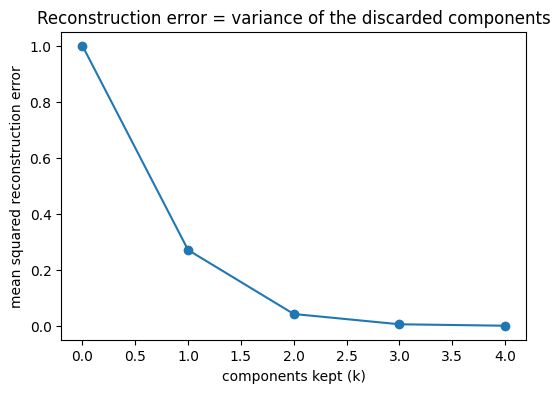

In [9]:
p = Z.shape[1]
mse, predicted = [], []
for k_ in range(0, p + 1):
    Wk = eigvecs[:, :k_]
    Z_hat = Z @ Wk @ Wk.T
    mse.append(np.mean((Z - Z_hat) ** 2))
    predicted.append(eigvals[k_:].sum() * (n - 1) / (n * p))
assert np.allclose(mse, predicted)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(p + 1), mse, "o-")
ax.set_xlabel("components kept (k)")
ax.set_ylabel("mean squared reconstruction error")
ax.set_title("Reconstruction error = variance of the discarded components")
plt.show()

## Takeaways
- PCA is an eigen-decomposition of the covariance matrix: the axes are eigenvectors and the variances are eigenvalues. scikit-learn gets the same answer through an SVD.
- Standardising first matters whenever features have different units or scales.
- Component signs are arbitrary. Compare PCA results only up to sign.
- On Iris, two components keep about 96 % of the variance, which is why the 2-D plot separates the species so well.